In [3]:
from scdiff.quality import rf_discriminability
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import StandardScaler
from scdiff.ae import LightningAE
from scdiff.plot import compare_umap
from scdiff.quality import rf_discriminability, knn_discriminability

In [ ]:
# Data reading and preprocessing
muris = sc.read_h5ad('../data/tabula_muris/all.h5ad')
np.random.seed(42)
# Data preprocessing and filtering: we keep a 10000x1000 subset of data
# Randomly pick 10000 cells and keep the 1000 most variable genes
muris.var_names_make_unique()
sc.pp.filter_cells(muris, min_genes=10)
sc.pp.filter_genes(muris, min_cells=2)

muris_10k =  muris[np.random.choice(muris.n_obs, 10000, replace=False)]
sc.pp.highly_variable_genes(muris_10k, flavor='seurat_v3', n_top_genes=1000)
muris_10k = muris_10k[:, muris_10k.var['highly_variable']]
muris_10k = muris_10k.copy()
muris_10k.X = muris_10k.X.toarray() # convert to dense matrix 
muris_10k.X

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:178: Trying to modify attribute `._uns` of view, initializing view as actual.


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 1000), dtype=float32)

In [14]:
# Fitting scdesigner simulator
from scdesigner.simulators import NegBinCopula

nbc = NegBinCopula(mean_formula = "~ celltype")
nbc.fit(muris_10k, max_epochs=300, top_k=100)
nbc_samples = nbc.sample(obs=muris_10k.obs)


Estimating top-k copula covariance: 100%|██████████| 10/10 [00:02<00:00,  3.75it/s]


946 935


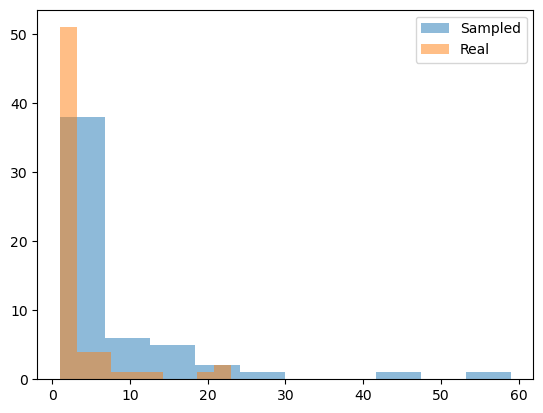

In [15]:
# visualizing marginal distribution of the 3rd gene
sampled_3rd_gene = nbc_samples.X[3]
real_3rd_gene = muris_10k.X[3]
sampled_3rd_gene_zero_counts = np.sum(sampled_3rd_gene == 0)
real_3rd_gene_zero_counts = np.sum(real_3rd_gene == 0)
print(sampled_3rd_gene_zero_counts, real_3rd_gene_zero_counts)
non_zero_sampled_3rd_gene = sampled_3rd_gene[sampled_3rd_gene != 0]
non_zero_real_3rd_gene = real_3rd_gene[real_3rd_gene != 0]

# compare the distribution of the 3rd gene
plt.hist(non_zero_sampled_3rd_gene, alpha=0.5, label='Sampled')
plt.hist(non_zero_real_3rd_gene, alpha=0.5, label='Real')
plt.legend()
plt.show()

In [ ]:
nbc_gene_cell_matrix = nbc_samples.X.T
real_gene_cell_matrix = muris_10k.X.T

gene_cell_auc, gene_cell_accuracy = knn_discriminability(real_gene_cell_matrix, nbc_gene_cell_matrix, 10)

cell_gene_auc, cell_gene_accuracy = knn_discriminability(nbc_samples.X, muris_10k.X, 10)

print("Discriminability by genes: ", gene_cell_auc, gene_cell_accuracy)
print("Discriminability by cells: ", cell_gene_auc, cell_gene_accuracy)

Discriminability by genes:  0.8816135084427767 0.8025
Discriminability by cells:  0.8965443700939777 0.77825


In [ ]:
# Training AE+diffusion Simulators
from scdiff.dataset import ScDataModule
from scdiff.lightning_diffusion import LightningDiffusion
import pytorch_lightning as pl
import anndata as ad 
import os

# NormalLog1p transformation
processed_muris_10k = muris_10k.copy()
sc.pp.normalize_total(processed_muris_10k, target_sum=10000)
sc.pp.log1p(processed_muris_10k)

murisData = ScDataModule(processed_muris_10k, "celltype", "LabelEncoder")
ae = LightningAE(n_genes=processed_muris_10k.X.shape[1])

trainer = pl.Trainer(
    max_epochs=100, # may need more training
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/sim_bottleneck/ae"
)

ae_path = "checkpoints/sim_bottleneck/ae/trained_ae.ckpt"
if os.path.exists(ae_path):
    ae = LightningAE.load_from_checkpoint(ae_path)
else:
    trainer.fit(ae, murisData)
    trainer.save_checkpoint(ae_path)

device = next(ae.parameters()).device
X_tensor = torch.tensor(processed_muris_10k.X, dtype=torch.float32, device=device)
ae.eval()
with torch.no_grad():
    X_encoded = ae.encode(X_tensor).cpu().numpy()
    
standard_scaler = StandardScaler()
X_encoded = standard_scaler.fit_transform(X_encoded)
encoded_muris_10k = ad.AnnData(X_encoded, obs=muris_10k.obs)
latent_dm = ScDataModule(encoded_muris_10k, "celltype", "LabelEncoder")
latent_dm.setup()

dim = encoded_muris_10k.X.shape[1]
num_classes = int(latent_dm.train_dataset.dataset.classes.max()) + 1


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: Some cells have zero counts
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | encoder   | Encoder | 3.3 M  | train
1 | decoder   | Decoder | 3.3 M  | train
2 | criterion | MSELoss | 0      | train
----------------------------------------------
6.5 M     Trainable params
0         Non-trainable params
6.5 M     Total params
26.096    Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [25]:
# Training diffusion model
diffusion = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes,
    use_ema=True,
    ema_decay=0.999
    )

trainer = pl.Trainer(
    max_epochs=100,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/sim_bottleneck/diffusion"
)

diffusion_path = "checkpoints/sim_bottleneck/diffusion/trained_diffusion.ckpt"
if os.path.exists(diffusion_path):
    diffusion = LightningDiffusion.load_from_checkpoint(diffusion_path)
else:
    trainer.fit(diffusion, latent_dm)
    trainer.save_checkpoint(diffusion_path)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | model     | DenoisingUNet     | 7.2 M  | train
1 | diffusion | GaussianDiffusion | 7.2 M  | train
2 | ema_model | DenoisingUNet     | 7.2 M  | eval 
--------------------------------------------------------
7.2 M     Trainable params
7.2 M     Non-trainable params
14.3 M    Total params
57.378    Total estimated model params size (MB)
92        Modules in train mode
91        Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:527: Found 91 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ -6.3155265,  18.920797 ],
         [ -8.752571 ,  19.696152 ],
         [-10.027395 ,  24.115921 ],
         ...,
         [ -5.188047 ,  22.23173  ],
         [ -6.8951216,  22.815165 ],
         [ -5.456034 ,  15.394826 ]], shape=(10000, 2), dtype=float32),
  array([[ -7.507967,  22.027445],
         [ -8.871831,  21.40433 ],
         [-11.599938,  22.480202],
         ...,
         [ -5.22577 ,  22.517702],
         [ -9.492841,  20.54369 ],
         [-10.701328,  20.369116]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

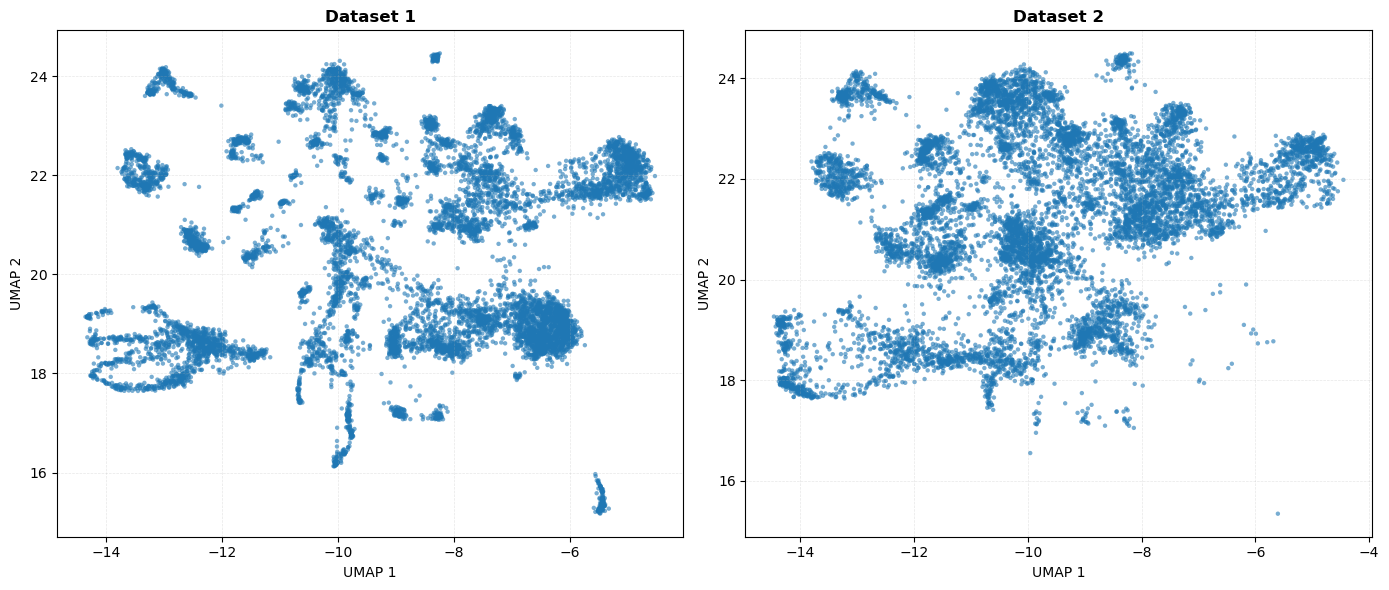

In [26]:
# sampling from diffusion model
diffusion.eval()
with torch.no_grad():
    latent_samples = diffusion.sample(num_samples=10000,
                                    sampling_timesteps=diffusion.diffusion.num_timesteps,
                                    ddim_sampling_eta=0.0,
                                    use_ema=True,
                                    clip_denoised=False, 
                                    )
latent_samples = latent_samples.cpu().numpy() 
compare_umap([X_encoded, latent_samples])

In [27]:
knn_discriminability(X_encoded, latent_samples, 10)

(0.6422200198216056, 0.5485)

In [28]:
it_latent_samples = standard_scaler.inverse_transform(latent_samples)
it_latent_samples = torch.tensor(it_latent_samples).to(device=device, dtype=torch.float32)
with torch.no_grad():
    decoded_samples = ae.decode(it_latent_samples).cpu().numpy()

In [ ]:
knn_discriminability(processed_muris_10k.X, decoded_samples, 10)

(0.9397918731417245, 0.85275)

Performing UMAP on combined dataset (20000 samples, 1000 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[-4.806955 ,  7.369127 ],
         [-4.4327164,  6.388101 ],
         [-4.3571916, -1.5073363],
         ...,
         [-9.346839 , -0.3799899],
         [-6.0962796,  5.598185 ],
         [-3.2755477,  5.7401004]], shape=(10000, 2), dtype=float32),
  array([[-7.5693655 , -2.123753  ],
         [-4.7460284 ,  0.11865653],
         [-2.511472  , -0.09140158],
         ...,
         [-8.900412  , -0.8073472 ],
         [-4.7344093 ,  2.0597508 ],
         [-7.1522784 , -0.12304569]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

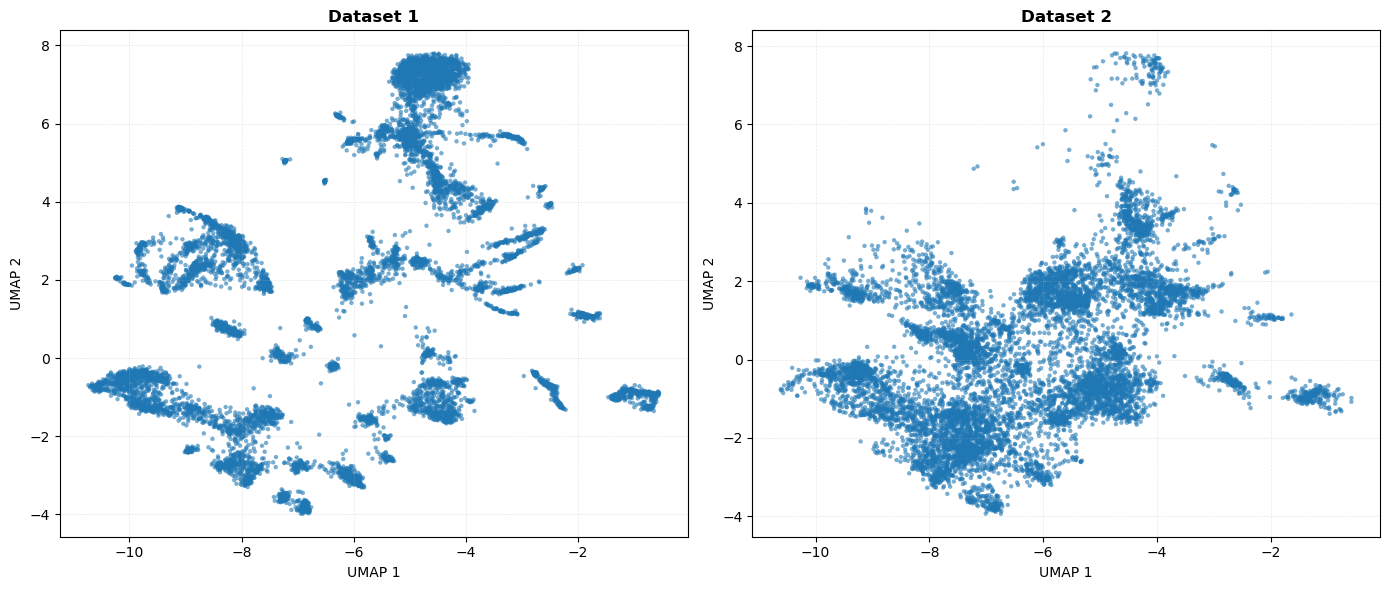

In [30]:
compare_umap([processed_muris_10k.X, decoded_samples])

Performing UMAP on combined dataset (30000 samples, 1000 features) across 3 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 2.3678741 ,  3.835584  ],
         [ 1.6277161 ,  4.640323  ],
         [ 0.88871366, 14.572858  ],
         ...,
         [-0.7416927 , 11.022144  ],
         [ 0.03140793,  6.3091    ],
         [ 3.3944707 ,  6.136835  ]], shape=(10000, 2), dtype=float32),
  array([[ 2.7253957,  4.647356 ],
         [ 2.047977 ,  3.879086 ],
         [ 1.3663621,  6.817849 ],
         ...,
         [-1.4980671,  9.636189 ],
         [ 1.4332187,  5.5330386],
         [ 3.359139 ,  7.413105 ]], shape=(10000, 2), dtype=float32),
  array([[-1.2093459 , 13.035997  ],
         [ 1.4210773 , 14.244387  ],
         [ 3.0115695 , 16.235226  ],
         ...,
         [-0.10670921, 14.060627  ],
         [ 1.458048  , 11.34641   ],
         [ 2.0850396 , 12.2398205 ]], shape=(10000, 2), dtype=float32)],
 <Figure size 2100x600 with 3 Axes>)

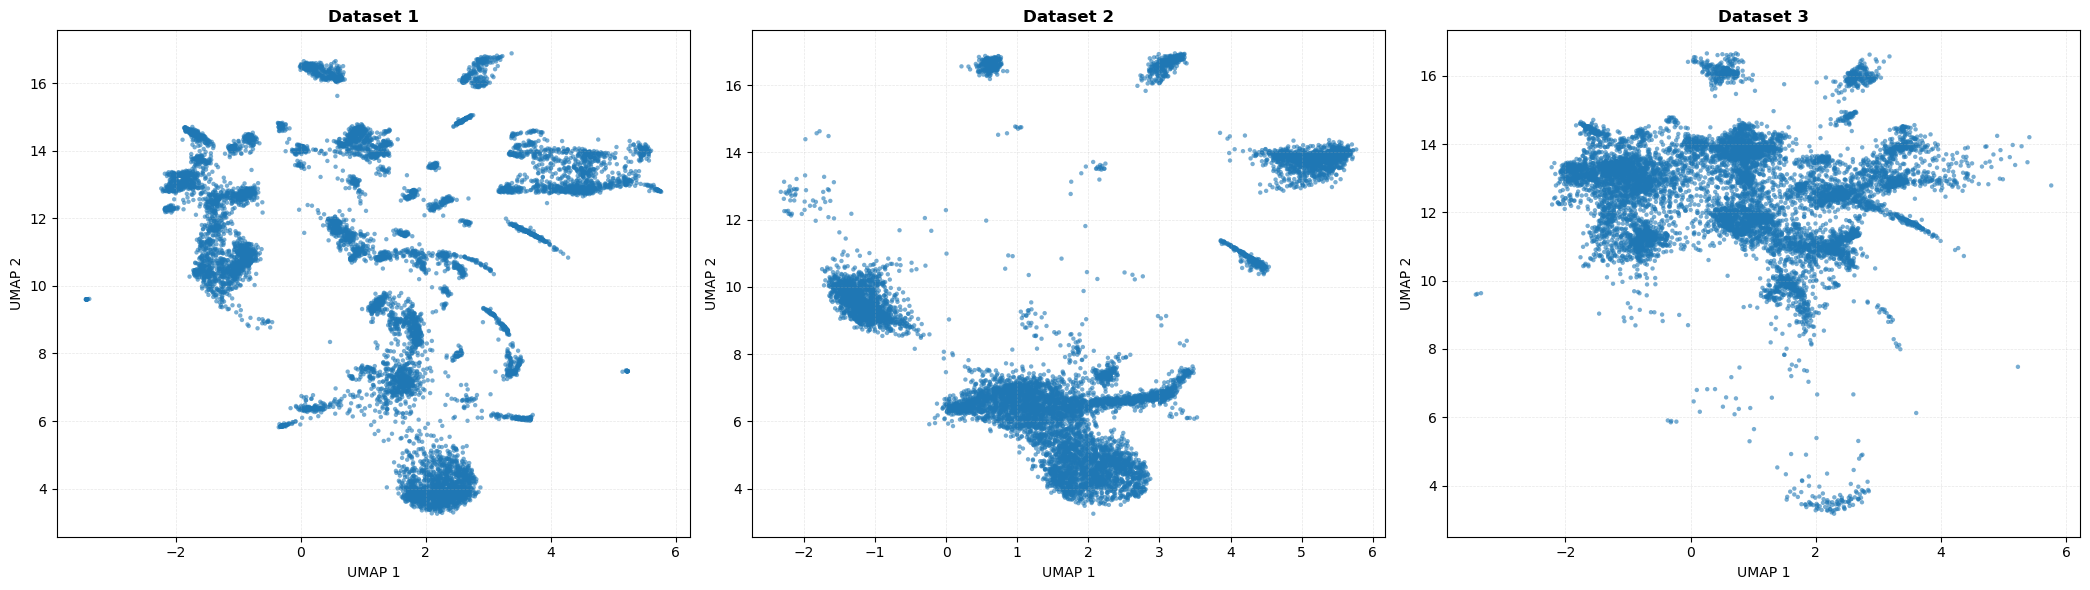

In [31]:
processed_nbc_samples = nbc_samples.copy()
sc.pp.normalize_total(processed_nbc_samples, target_sum=10000)
sc.pp.log1p(processed_nbc_samples)

compare_umap([processed_muris_10k.X, processed_nbc_samples.X, decoded_samples])

Performing UMAP on combined dataset (30000 samples, 128 features) across 3 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 6.9686704 , 20.077005  ],
         [ 3.0762832 , 20.165573  ],
         [ 0.98258775, 23.870413  ],
         ...,
         [ 2.8602643 , 25.211824  ],
         [ 4.3248773 , 21.23276   ],
         [ 5.8873105 , 17.363214  ]], shape=(10000, 2), dtype=float32),
  array([[ 2.0486312 , 22.057062  ],
         [ 2.7626    , 21.701845  ],
         [-0.94618326, 21.997147  ],
         ...,
         [ 3.06905   , 24.83388   ],
         [-1.008689  , 21.807676  ],
         [ 2.0229654 , 20.825115  ]], shape=(10000, 2), dtype=float32),
  array([[ 6.5025277, 19.716576 ],
         [ 6.805839 , 20.83036  ],
         [ 7.001971 , 18.888447 ],
         ...,
         [ 4.090356 , 24.946917 ],
         [ 6.712248 , 19.467388 ],
         [ 4.153473 , 17.388008 ]], shape=(10000, 2), dtype=float32)],
 <Figure size 2100x600 with 3 Axes>)

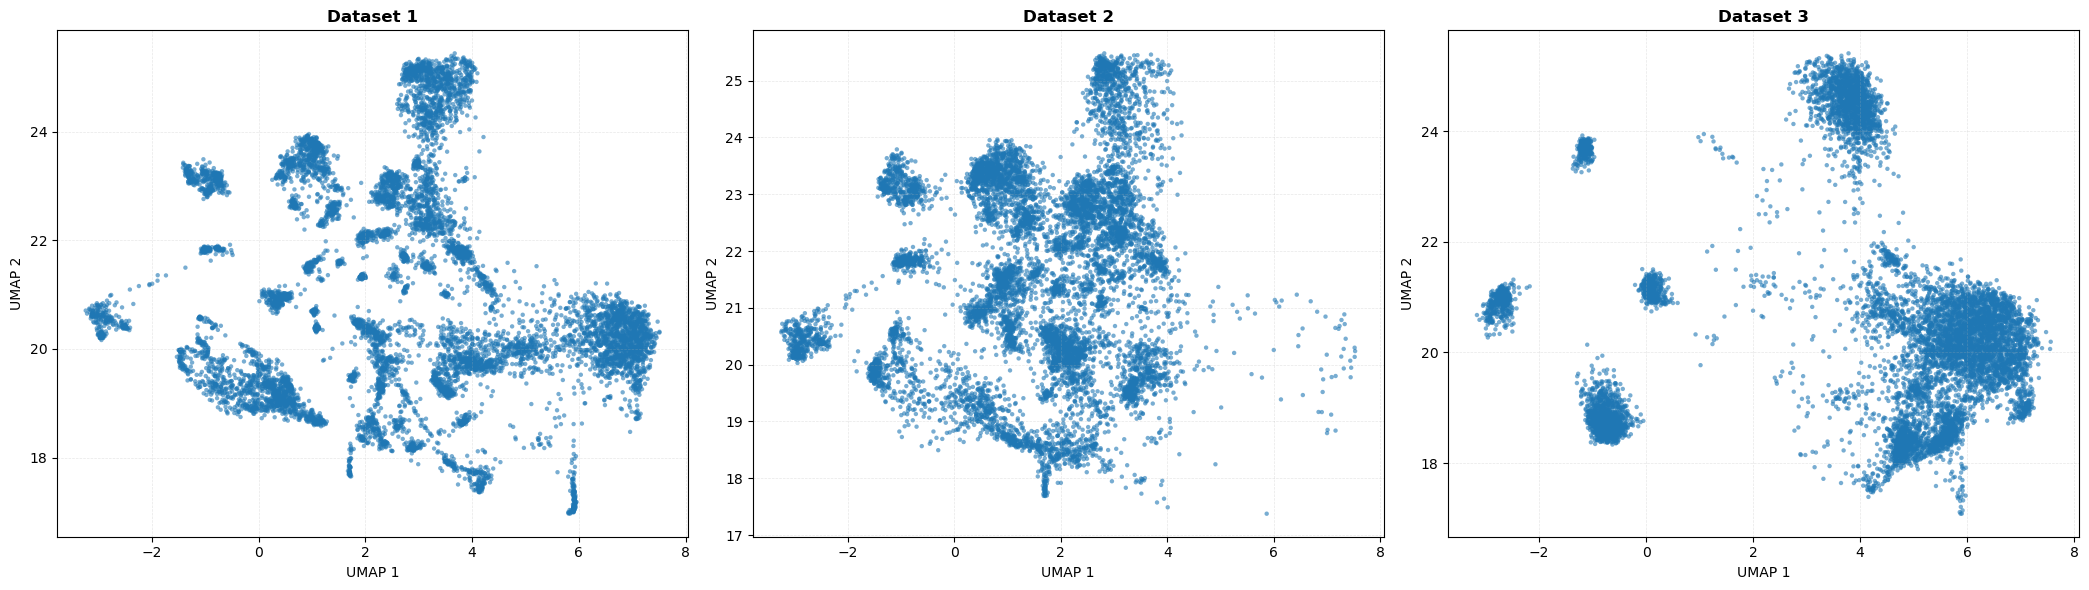

In [32]:
with torch.no_grad():
    encoded_nbc_samples = ae.encode(torch.tensor(processed_nbc_samples.X, 
                                             dtype=torch.float32, device=device))
encoded_nbc_samples = standard_scaler.transform(encoded_nbc_samples)
compare_umap([X_encoded,latent_samples, encoded_nbc_samples]) 

In [33]:
knn_discriminability(X_encoded, encoded_nbc_samples, 10)

(0.9011512432507033, 0.703)